# Analyse de la relation entre consommation d'espace et croissance démographique

In [1]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm  # Pour la régression linéaire

In [2]:
# Charger les données depuis les fichiers CSV
conso = pd.read_csv('../inputs/csv/conso2009_2023_resultats_com.csv', sep=';', dtype={'idcom': str})
aav = pd.read_csv('../inputs/csv/AAV2020_au_01-01-2024.csv', sep=';', dtype={'AAV2020': str})
pop = pd.read_csv('../inputs/csv/base-pop-historiques-1876-2022.csv', sep=';', dtype={'CODGEO': str})

C:\Users\X515\AppData\Local\Temp\ipykernel_19080\3950086776.py:2: DtypeWarning: Columns (4,6) have mixed types. Specify dtype option on import or set low_memory=False.
  conso = pd.read_csv('../inputs/csv/conso2009_2023_resultats_com.csv', sep=';', dtype={'idcom': str})
C:\Users\X515\AppData\Local\Temp\ipykernel_19080\3950086776.py:4: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  pop = pd.read_csv('../inputs/csv/base-pop-historiques-1876-2022.csv', sep=';', dtype={'CODGEO': str})


In [3]:
# Préparer les indicateurs
# Consommation totale NAF -> artificialisé par commune
conso_comm = conso[['idcom', 'naf09art23']].copy()

# Calculer la croissance démographique 2014-2020 par commune
pop20 = pop[['CODGEO', 'PMUN2020']].rename(columns={'PMUN2020': 'pop2020'})
pop14 = pop[['CODGEO', 'PMUN2014']].rename(columns={'PMUN2014': 'pop2014'})
pop_growth = pop20.merge(pop14, on='CODGEO', how='inner')
pop_growth['pop_growth_pct'] = (pop_growth['pop2020'] - pop_growth['pop2014']) / pop_growth['pop2014'] * 100

# affcichage pour voir si cela fonctionne
print(pop_growth.head())
print(conso_comm.head())
print(aav.head())


  CODGEO  pop2020  pop2014  pop_growth_pct
0  01001      806      767        5.084746
1  01002      262      239        9.623431
2  01004    14288    14022        1.897019
3  01005     1782     1627        9.526736
4  01006      113      109        3.669725
   idcom  naf09art23
0  01001       67511
1  01002       14600
2  01004      610116
3  01005      122101
4  01006        6507
  AAV2020                          LIBAAV2020  TAAV2017  TDAAV2017  NB_COM
0     000  Commune hors attraction des villes         0          0    8921
1     001                               Paris         5         50    1929
2     002                                Lyon         4         42     397
3     003         Marseille - Aix-en-Provence         4         42     115
4     004            Lille (partie française)         4         42     201


In [7]:
# S'assurer que la colonne 'aav2020' dans conso est bien mise au format chaîne à 3 chiffres
conso['aav2020'] = conso['aav2020'].astype(str).str.zfill(3)

# On utilise conso pour disposer de la colonne 'aav2020'
df = conso.merge(pop_growth[['CODGEO', 'pop_growth_pct']], 
                 left_on='idcom', right_on='CODGEO', how='inner') \
          .merge(aav[['AAV2020', 'LIBAAV2020']], 
                 left_on='aav2020', right_on='AAV2020', how='left')
print(df[['idcom', 'naf09art23', 'aav2020', 'LIBAAV2020', 'pop_growth_pct']].head())

   idcom  naf09art23                         aav2020 LIBAAV2020  \
0  01001       67511  524 - Châtillon-sur-Chalaronne        NaN   
1  01002       14600                N/A - hors champ        NaN   
2  01004      610116         243 - Ambérieu-en-Bugey        NaN   
3  01005      122101                      002 - Lyon        NaN   
4  01006        6507                    286 - Belley        NaN   

   pop_growth_pct  
0        5.084746  
1        9.623431  
2        1.897019  
3        9.526736  
4        3.669725  


In [8]:
# Vérification et nettoyage des données
df.isnull().sum()  # Vérification des valeurs manquantes

# Supprimer les valeurs manquantes ou infinies
df = df.dropna(subset=['naf09art23', 'pop_growth_pct'])
df = df[~df['pop_growth_pct'].isin([float('inf'), float('-inf')])]  # Supprimer les valeurs infinies

# affichage pour voir si cela fonctionne
print(df.isnull().sum())  # Vérification des valeurs manquantes après nettoyage
print(df.head())  # Affichage des premières lignes du DataFrame après nettoyage


idcom                 0
idcomtxt              0
idreg                 0
idregtxt              0
iddep                 0
                  ...  
surfcom2023           0
CODGEO                0
pop_growth_pct        0
AAV2020           34898
LIBAAV2020        34898
Length: 135, dtype: int64
   idcom                 idcomtxt  idreg              idregtxt iddep iddeptxt  \
0  01001  L"Abergement-Clémenciat     84  Auvergne-Rhône-Alpes     1      Ain   
1  01002    L"Abergement-de-Varey     84  Auvergne-Rhône-Alpes     1      Ain   
2  01004        Ambérieu-en-Bugey     84  Auvergne-Rhône-Alpes     1      Ain   
3  01005      Ambérieux-en-Dombes     84  Auvergne-Rhône-Alpes     1      Ain   
4  01006                  Ambléon     84  Auvergne-Rhône-Alpes     1      Ain   

      epci23                 epci23txt                         scot  \
0  200069193           CC de la Dombes            SCoT de la Dombes   
1  240100883  CC de la Plaine de l"Ain                  SCoT BUCOPA   
2  2401008

In [13]:
# Remove rows where LIBAAV2020 is missing
df_clean = df.dropna(subset=['LIBAAV2020'])

# Agréger par aire urbaine
grouped = df_clean.groupby('LIBAAV2020').agg({
    'naf09art23': 'sum',
    'pop_growth_pct': 'mean'
}).reset_index()

print(grouped.head())

Empty DataFrame
Columns: [LIBAAV2020, naf09art23, pop_growth_pct]
Index: []


In [15]:
# Créer la colonne 'total_naf_consumed'
grouped = grouped.rename(columns={'naf09art23': 'total_naf_consumed'})

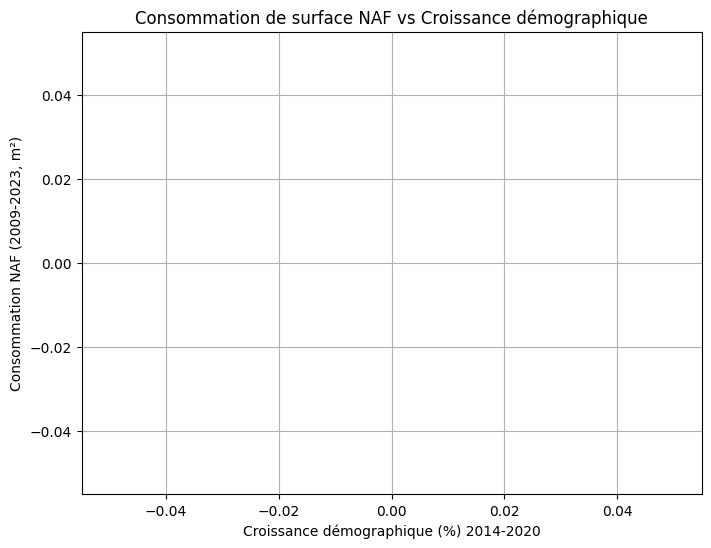

In [16]:
# Visualisation des données - Graphique de dispersion
plt.figure(figsize=(8,6))
plt.scatter(grouped['pop_growth_pct'], grouped['total_naf_consumed'], label='Données')
plt.xlabel('Croissance démographique (%) 2014-2020')
plt.ylabel('Consommation NAF (2009-2023, m²)')
plt.title('Consommation de surface NAF vs Croissance démographique')
plt.grid(True)
plt.show()

In [ ]:
# Préparer les données pour la régression
X = grouped['pop_growth_pct'].values.reshape(-1, 1)  # Variable indépendante (croissance démographique)
y = grouped['total_naf_consumed'].values  # Variable dépendante (consommation de terrain NAF)

In [ ]:
# Appliquer le modèle de régression linéaire avec PyNiB
model = OLS(X, y)  # Initialiser le modèle de régression
results = model.fit()  # Ajuster le modèle aux données

In [ ]:
# Résumé du modèle
results.summary()

In [ ]:
# Afficher la ligne de régression sur le graphique
plt.figure(figsize=(8,6))
plt.scatter(grouped['pop_growth_pct'], grouped['total_naf_consumed'], label='Données')
plt.plot(grouped['pop_growth_pct'], results.fittedvalues, color='red', label='Régression linéaire')
plt.xlabel('Croissance démographique (%) 2014-2020')
plt.ylabel('Consommation NAF (2009-2023, m²)')
plt.title('Consommation de surface NAF vs Croissance démographique avec régression linéaire')
plt.legend()
plt.grid(True)
plt.show()